# Уровень заработной платы в России

В файле записаны данные о заработной плате за каждый месяц с января 1993 по август 2016. 
Необходимо проанализировать данные, подобрать для них оптимальную прогнозирующую модель в классе ARIMA и построить прогноз на каждый месяц на два года вперёд от конца данных.

In [1]:
%pylab inline
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
from itertools import product

def invboxcox(y,lmbda):
   if lmbda == 0:
      return(np.exp(y))
   else:
      return(np.exp(np.log(lmbda*y+1)/lmbda))

Populating the interactive namespace from numpy and matplotlib


In [8]:
wag = pd.read_csv('WAG_C_M.csv',';', index_col=['month'], parse_dates=['month'], dayfirst=True)
wag.head()

,WAG_C_M
month,
1993-01-01,15.3
1993-02-01,19.1
1993-03-01,23.6
1993-04-01,30.6
1993-05-01,37.5


#### Визуальный анализ ряда

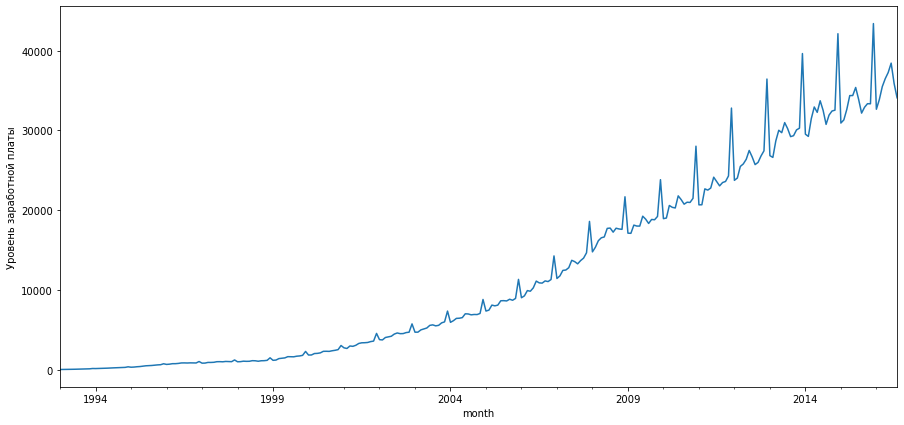

In [9]:
plt.figure(figsize(15,7))
wag.WAG_C_M.plot()
plt.ylabel('Уровень заработной платы')
pylab.show()

Явно виден возрастающий тренд, но проверим формально признак стационарности критерием Дики-Фуллера.

#### Проверка стационарности и STL-декомпозиция ряда

Критерий Дики-Фуллера: p=0.991850


<Figure size 1080x720 with 0 Axes>

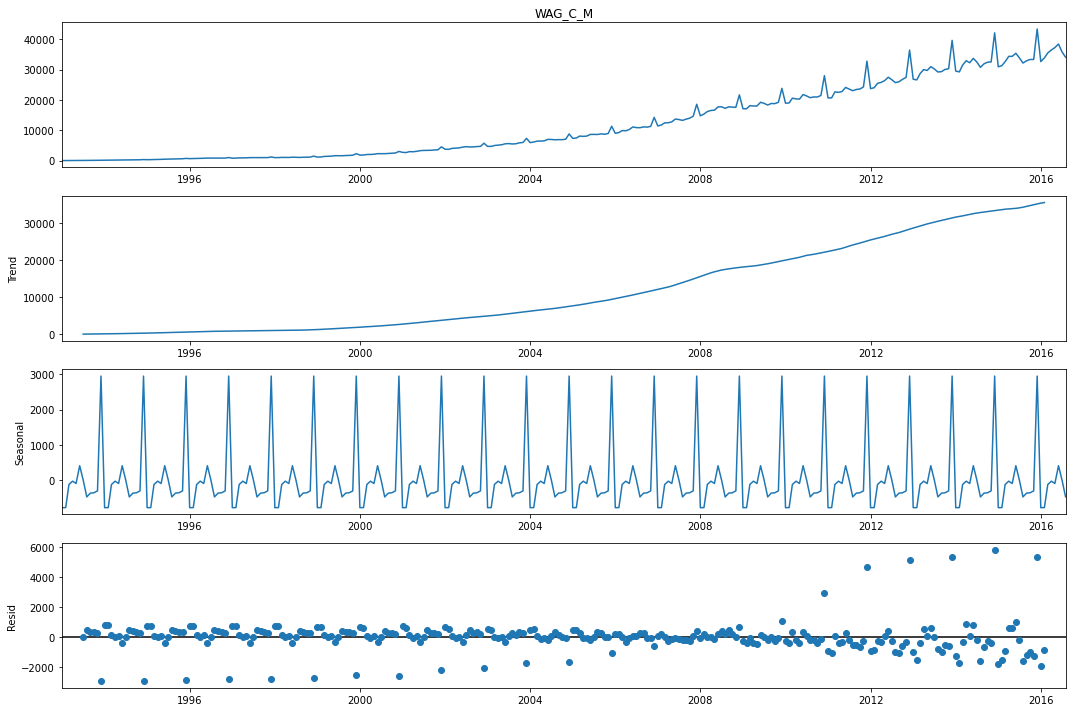

In [10]:
plt.figure(figsize(15,10))
sm.tsa.seasonal_decompose(wag.WAG_C_M).plot()
print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(wag.WAG_C_M)[1])

Очевидно, что гипотеза о нестационарности ряда не отвергается.
На графике Seasonal хороша видна сезонность ряда с периодом 12 месяцев (1 год).
Запишем её сразу в переменную:

In [12]:
S = 12

На исходном графике явно видно увеличение амплитуды со временем.

Сделаем преобразование Бокса-Кокса для стабилизации дисперсии.

#### Стабилизация дисперсии

Оптимальный параметр преобразования Бокса-Кокса: 0.263202
Критерий Дики-Фуллера: p=0.696899


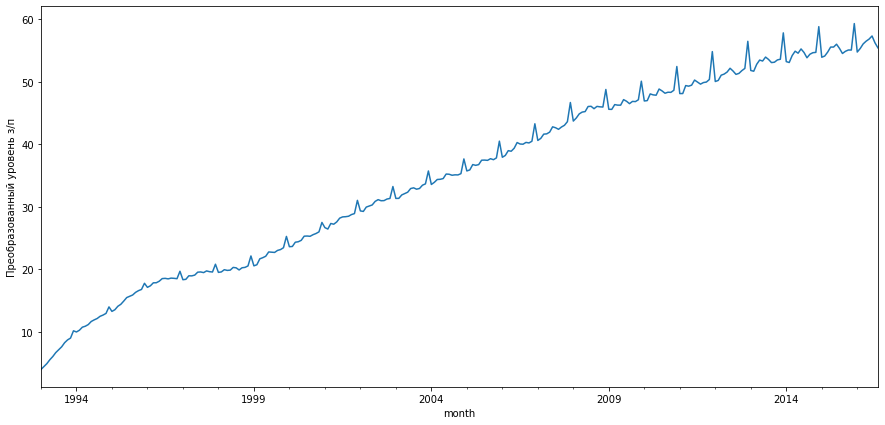

In [14]:
wag['wag_box'], lmbda = stats.boxcox(wag.WAG_C_M)
plt.figure(figsize(15,7))
wag.wag_box.plot()
plt.ylabel(u'Преобразованный уровень з/п')
print("Оптимальный параметр преобразования Бокса-Кокса: %f" % lmbda)
print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(wag.wag_box)[1])

Дисперсия уменьшилась, но ряд, по прежнему, не стационарен, т.к. имеет явно возрастающий тренд.

Сделаем сезонное дифференцирование. И сразу запишем это в переменную D.

#### Cезонное дифференцирование

In [15]:
D = 1

Cделаем на продифференцированном ряде STL-декомпозицию и проверим стационарность.

Критерий Дики-Фуллера: p=0.014697


<Figure size 1080x720 with 0 Axes>

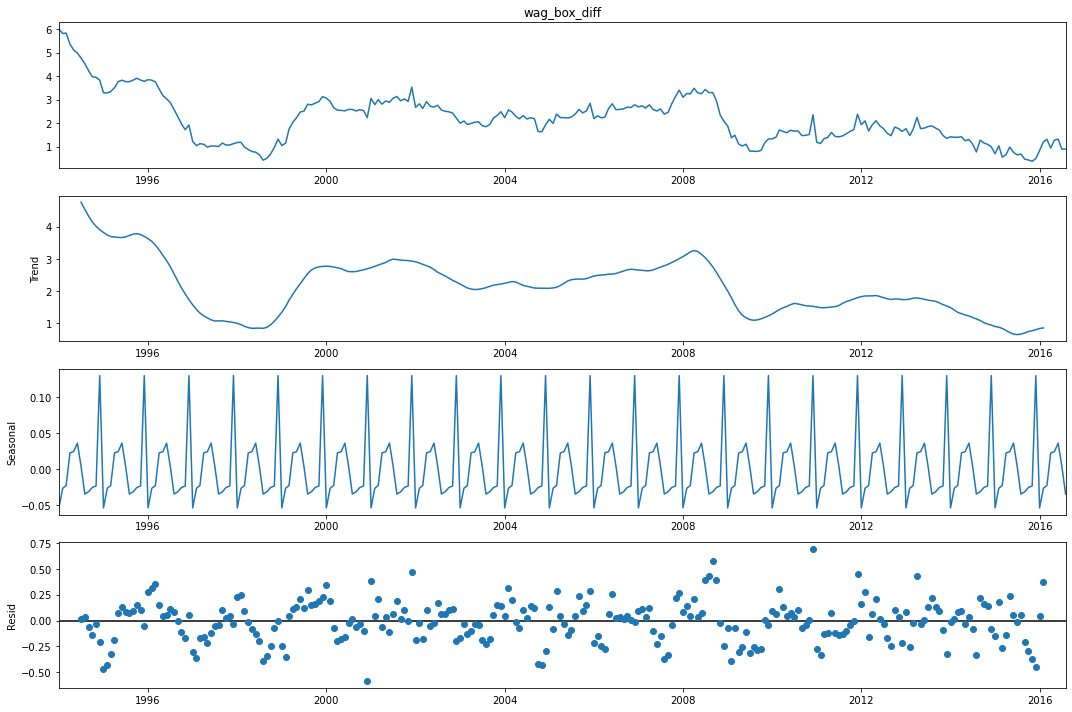

In [16]:
wag['wag_box_diff'] = wag.wag_box - wag.wag_box.shift(S)
plt.figure(figsize(15,10))
sm.tsa.seasonal_decompose(wag.wag_box_diff[S:]).plot()
print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(wag.wag_box_diff[S:])[1])

Ура! Критерий Дики-Фуллера отвергает гипотезу нестационарности на уровне 0.05, но избавиться от тренда не удалось - видно, что он понижающийся. Попробуем добавить ещё обычное дифференцирование, записав значение в переменную d.

#### Обычное дифференцирование

In [17]:
d = 1

Критерий Дики-Фуллера: p=5.203603715821677e-08


<Figure size 1080x720 with 0 Axes>

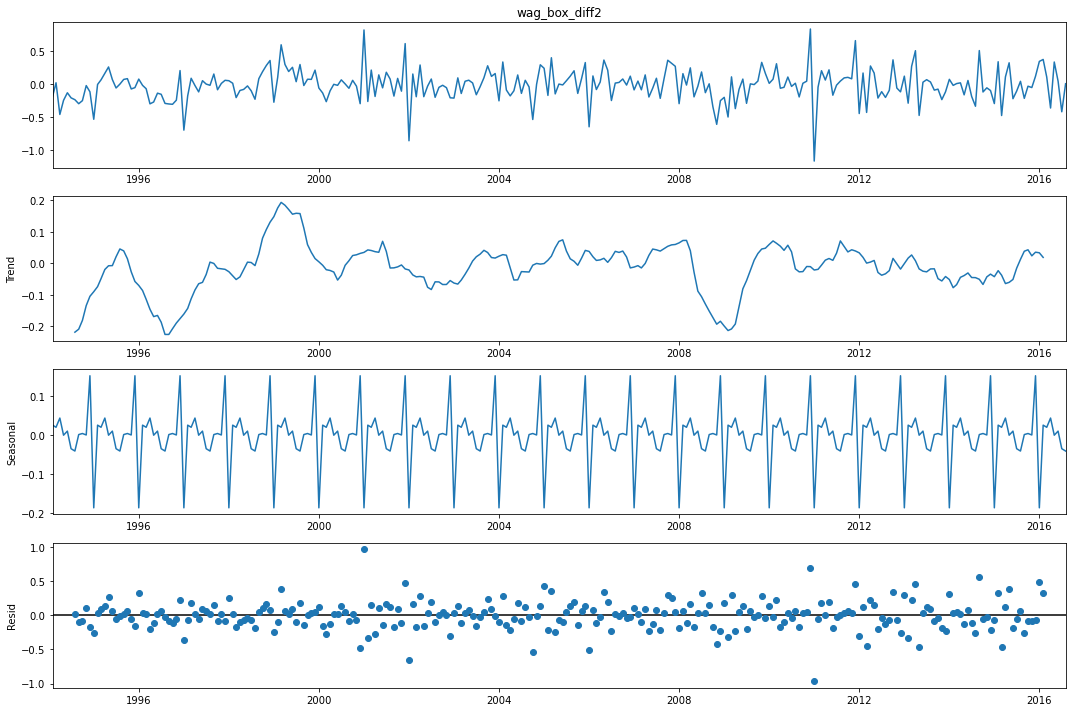

In [22]:
wag['wag_box_diff2'] = wag.wag_box_diff - wag.wag_box_diff.shift(1)
plt.figure(figsize(15,10))
sm.tsa.seasonal_decompose(wag.wag_box_diff2[S+1:]).plot()   
print(f"Критерий Дики-Фуллера: p={sm.tsa.stattools.adfuller(wag.wag_box_diff2[S+1:])[1]}")

Гипотеза нестационарности уверенно отвергается, и визуально ряд выглядит лучше — явного тренда больше нет. 

#### Подбор модели

Посмотрим на ACF и PACF полученного ряда.

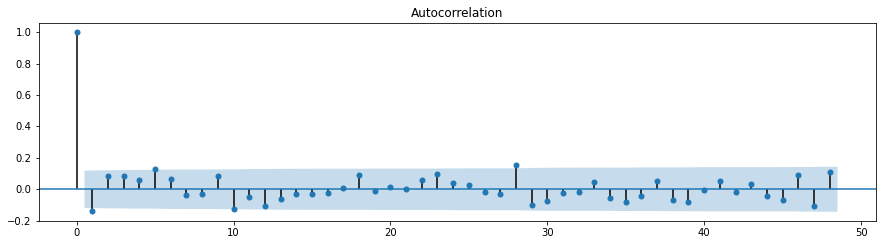

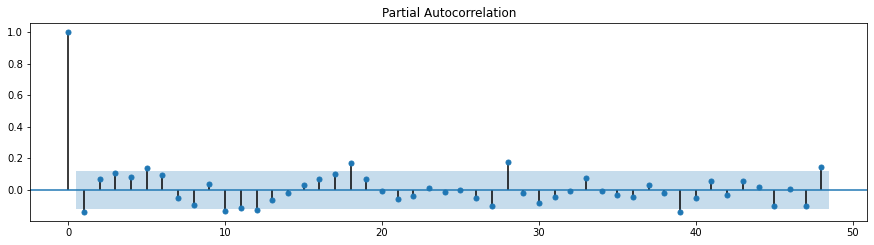

In [23]:
plt.figure(figsize(15,8))
ax = plt.subplot(211)
sm.graphics.tsa.plot_acf(wag.wag_box_diff2[S+1:].values.squeeze(), lags=48, ax=ax)
pylab.show()
ax = plt.subplot(212)
sm.graphics.tsa.plot_pacf(wag.wag_box_diff2[S+1:].values.squeeze(), lags=48, ax=ax)
pylab.show()

Из первого графика подбираем начальные приближения для Q и q, из второго - для P и p.

In [32]:
Q = 0
q = 5   # можно было бы взять 28, но при этом количество моделей резко возрастает
P = 4
p = 1   # можно было бы взять 10 или 11, но при этом количество моделей резко возрастает

Для тестирования нескольких моделей зададим диапазоны изменения этих параметров.

In [33]:
Qs = range(0, Q+1)
qs = range(0, q+1)
Ps = range(0, P+1)
ps = range(0, p+1)

Подсчитаем количество вариантов моделей.

In [34]:
parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
len(parameters_list)

60

Это количество вполне приемлемо. Строим модели...

In [35]:
%%time
results = []
best_aic = float("inf")
warnings.filterwarnings('ignore')

for param in parameters_list:
    #try except нужен, потому что на некоторых наборах параметров модель не обучается
    try:
        model=sm.tsa.statespace.SARIMAX(wag.wag_box, 
                                        order=(param[0], d, param[1]), 
                                        seasonal_order=(param[2], D, param[3], S)
                                       ).fit(disp=-1)
    #выводим параметры, на которых модель не обучается и переходим к следующему набору
    except ValueError:
        print('wrong parameters:', param)
        continue
    aic = model.aic
    #сохраняем лучшую модель, aic, параметры
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results.append([param, model.aic])
    
warnings.filterwarnings('default')

Wall time: 2min 42s


Выведем 5 лучших моделей (с наименьшим aic).

In [36]:
result_table = pd.DataFrame(results)
result_table.columns = ['parameters', 'aic']
print(result_table.sort_values(by = 'aic', ascending=True).head())

      parameters        aic
56  (1, 5, 1, 0) -15.867142
57  (1, 5, 2, 0) -14.851643
55  (1, 5, 0, 0) -13.661218
58  (1, 5, 3, 0) -12.987977
59  (1, 5, 4, 0) -12.861301


#### Модель-победитель

In [37]:
print(best_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             wag_box   No. Observations:                  284
Model:             SARIMAX(1, 1, 5)x(1, 1, [], 12)   Log Likelihood                  15.934
Date:                             Wed, 09 Jun 2021   AIC                            -15.867
Time:                                     18:54:45   BIC                             12.950
Sample:                                 01-01-1993   HQIC                            -4.297
                                      - 08-01-2016                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5843      0.153      3.813      0.000       0.284       0.885
ma.L1         -0.8117      

#### Анализ остатков модели

Критерий Стьюдента: p=0.281192
Критерий Дики-Фуллера: p=0.000000


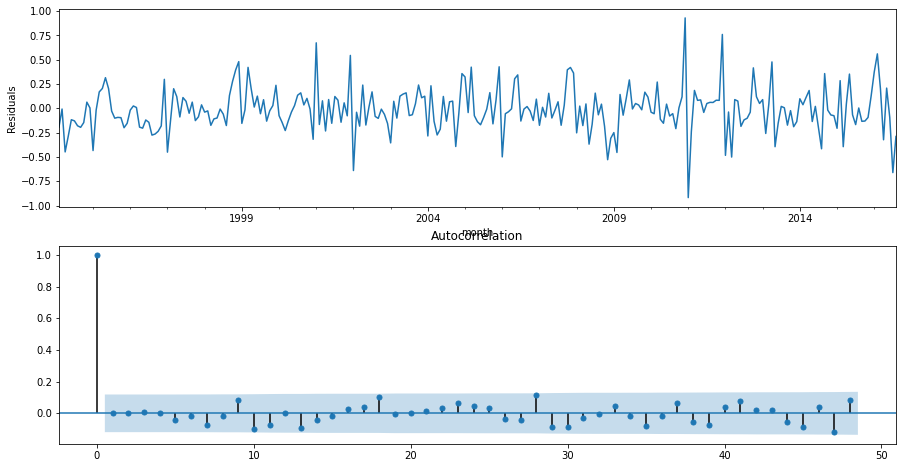

In [38]:
plt.figure(figsize(15,8))
plt.subplot(211)
best_model.resid[S+1:].plot()
plt.ylabel(u'Residuals')

ax = plt.subplot(212)
sm.graphics.tsa.plot_acf(best_model.resid[S+1:].values.squeeze(), lags=48, ax=ax)

print("Критерий Стьюдента: p=%f" % stats.ttest_1samp(best_model.resid[S+1:], 0)[1])
print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(best_model.resid[S+1:])[1])

Остатки несмещены (подтверждается критерием Стьюдента), стационарны (подтверждается критерием Дики-Фуллера и визуально), неавтокоррелированы (подтверждается критерием Льюнга-Бокса и коррелограммой).

Посмотрим, насколько хорошо модель описывает данные.

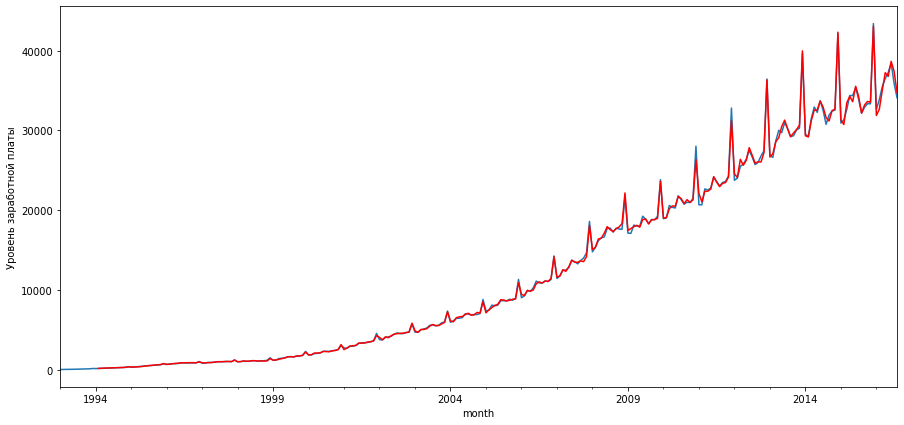

In [39]:
wag['model'] = invboxcox(best_model.fittedvalues, lmbda)
plt.figure(figsize(15,7))
wag.WAG_C_M.plot()
wag.model[S+1:].plot(color='r')
plt.ylabel('Уровень заработной платы')
pylab.show()

Выглядит совсем неплохо!

#### Прогноз

Построим прогноз на 2 года вперёд (это 24 месяца), начиная с сентября 2016 г.

In [42]:
delta = 24

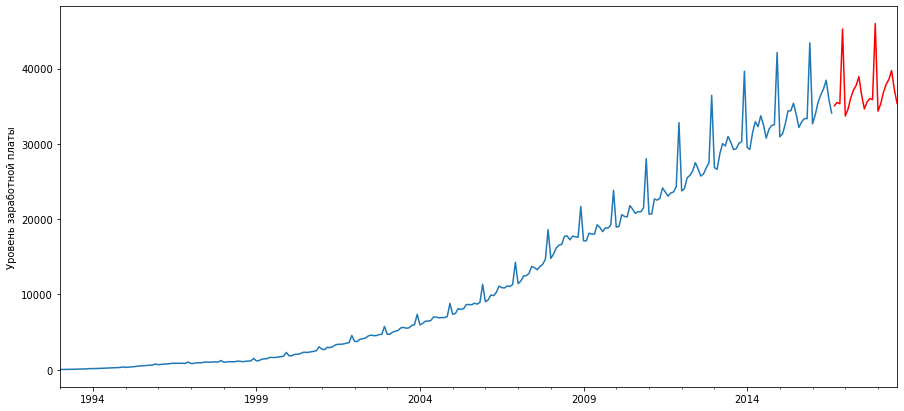

In [43]:
wag2 = wag[['WAG_C_M']]
date_list = [datetime.datetime.strptime("2016-09-01", "%Y-%m-%d") + relativedelta(months=x) for x in range(0, delta)]
future = pd.DataFrame(index=date_list, columns= wag2.columns)
wag2 = pd.concat([wag2, future])
wag2['forecast'] = invboxcox(best_model.predict(start=len(wag), end=len(wag)+delta-1), lmbda)

plt.figure(figsize(15,7))
wag2.WAG_C_M.plot()
wag2.forecast.plot(color='r')
plt.ylabel('Уровень заработной платы')
pylab.show()

#### Реальность

Сверим прогноз модели с реальными данными, взятыми с https://rosstat.gov.ru/labor_market_employment_salaries?print=1

За август 2016 г. данные разнятся (34095 в исходных данных и 35405 в новых), но это несущественно.

In [46]:
date_list = [datetime.datetime.strptime("2016-09-01", "%Y-%m-%d") + relativedelta(months=x) for x in range(0, delta)]
wag_real = pd.DataFrame(
    data=[35843,35749,36195,47554,34422,35497,37899,39225,39679,41454,38073,37099,38047,38333,38848,51197,39017,40443,42364,43381,44076,45848,42413,41364],
    index=date_list,
    columns=['wag']
)
wag_real.head()

,wag
2016-09-01,35843
2016-10-01,35749
2016-11-01,36195
2016-12-01,47554
2017-01-01,34422


На графике красным цветом будет показан прогноз, зелёным - реальные данные.

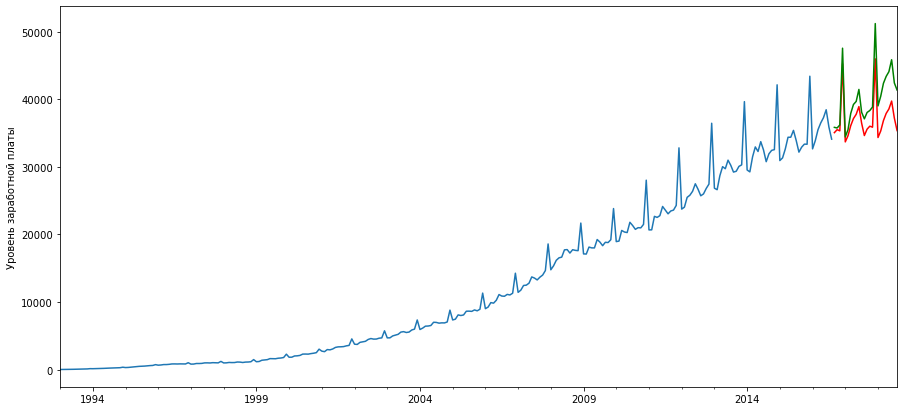

In [48]:
plt.figure(figsize(15,7))
wag2.WAG_C_M.plot()
wag2.forecast.plot(color='r')
wag_real.wag.plot(color='g')
plt.ylabel('Уровень заработной платы')
pylab.show()

Как видно, жизнь оказалась оптимистичнее пронозов - тренд сохранился более явно, чем предполагалось моделью :)

Но сезонные колебания и амплитуда переданы моделью весьма точно.